# 05 — All-Tissue Pathology Models (LR Baseline)

Run blood-based models for every tissue × category pair with ≥ 50 samples.

In [1]:
import pandas as pd
from trace_path.config import Config
from trace_path.data import load_cache
from trace_path.labels import discover_tissue_category_pairs
from trace_path.models import make_lr_pipeline
from trace_path.utils import run_all_tissue_models_parallel
from trace_path.evaluation import (
    plot_roc_grid, plot_pr_grid, plot_cm_grid, plot_boxplot_grid,
)

Config.ensure_dirs()

# Load cached data (run notebook 01 first)
X_wb, blood_subjid, _, df_meta_url, _ = load_cache()

Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/TRACE/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes


## Discover Tissue × Category Pairs

In [2]:
pairs_df = discover_tissue_category_pairs(df_meta_url)
print(f"Total pairs (≥ {Config.ALL_TISSUE_THRESHOLD} samples): {len(pairs_df)}")
display(pairs_df)

Total pairs (≥ 50 samples): 59


,tissue,category,n_samples
0,Adipose - Subcutaneous,fibrosis,270
1,Adipose - Visceral (Omentum),fibrosis,139
2,Artery - Aorta,atherosis,229
3,Artery - Aorta,plaque,112
4,Artery - Aorta,atherosclerosis,101
5,Artery - Aorta,sclerotic,64
6,Artery - Aorta,calcification,54
7,Artery - Coronary,calcification,159
8,Artery - Coronary,atherosclerosis,153
9,Artery - Coronary,sclerotic,124


## Run All Models (Parallelized by Tissue)

In [3]:
all_tissue_results, all_tissue_summary = run_all_tissue_models_parallel(
    pairs_df, df_meta_url, blood_subjid, X_wb, make_lr_pipeline
)
all_tissue_summary.to_csv(Config.TABLES_DIR / "cv_results_all_tissue_pathology.csv", index=False)
print(f"Completed {len(all_tissue_results)} models")
display(all_tissue_summary)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  7.0min


[Parallel(n_jobs=-1)]: Done   8 out of  20 | elapsed: 32.6min remaining: 48.9min


[Parallel(n_jobs=-1)]: Done  11 out of  20 | elapsed: 38.3min remaining: 31.3min


[Parallel(n_jobs=-1)]: Done  14 out of  20 | elapsed: 39.7min remaining: 17.0min


[Parallel(n_jobs=-1)]: Done  17 out of  20 | elapsed: 42.7min remaining:  7.5min


Completed 59 models


[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed: 104.2min finished


,tissue,category,mean_auc,std_auc,optimal_threshold
21,Breast - Mammary Tissue,atrophy,0.835538,0.040885,0.144591
35,Liver,cirrhosis,0.820400,0.070070,0.050908
19,Breast - Mammary Tissue,gynecomastoid,0.800473,0.042560,0.180916
53,Spleen,congestion,0.758843,0.054069,0.893157
49,Pancreas,saponification,0.750429,0.053161,0.341961
20,Breast - Mammary Tissue,hyperplasia,0.714884,0.033618,0.138631
27,Heart - Left Ventricle,hypertrophy,0.693946,0.064580,0.012877
42,Lung,pneumonia,0.685156,0.023627,0.061624
45,Muscle - Skeletal,atrophy,0.658333,0.172003,0.705337
48,Ovary,atrophy,0.630856,0.056189,0.088141


## Evaluation Plots

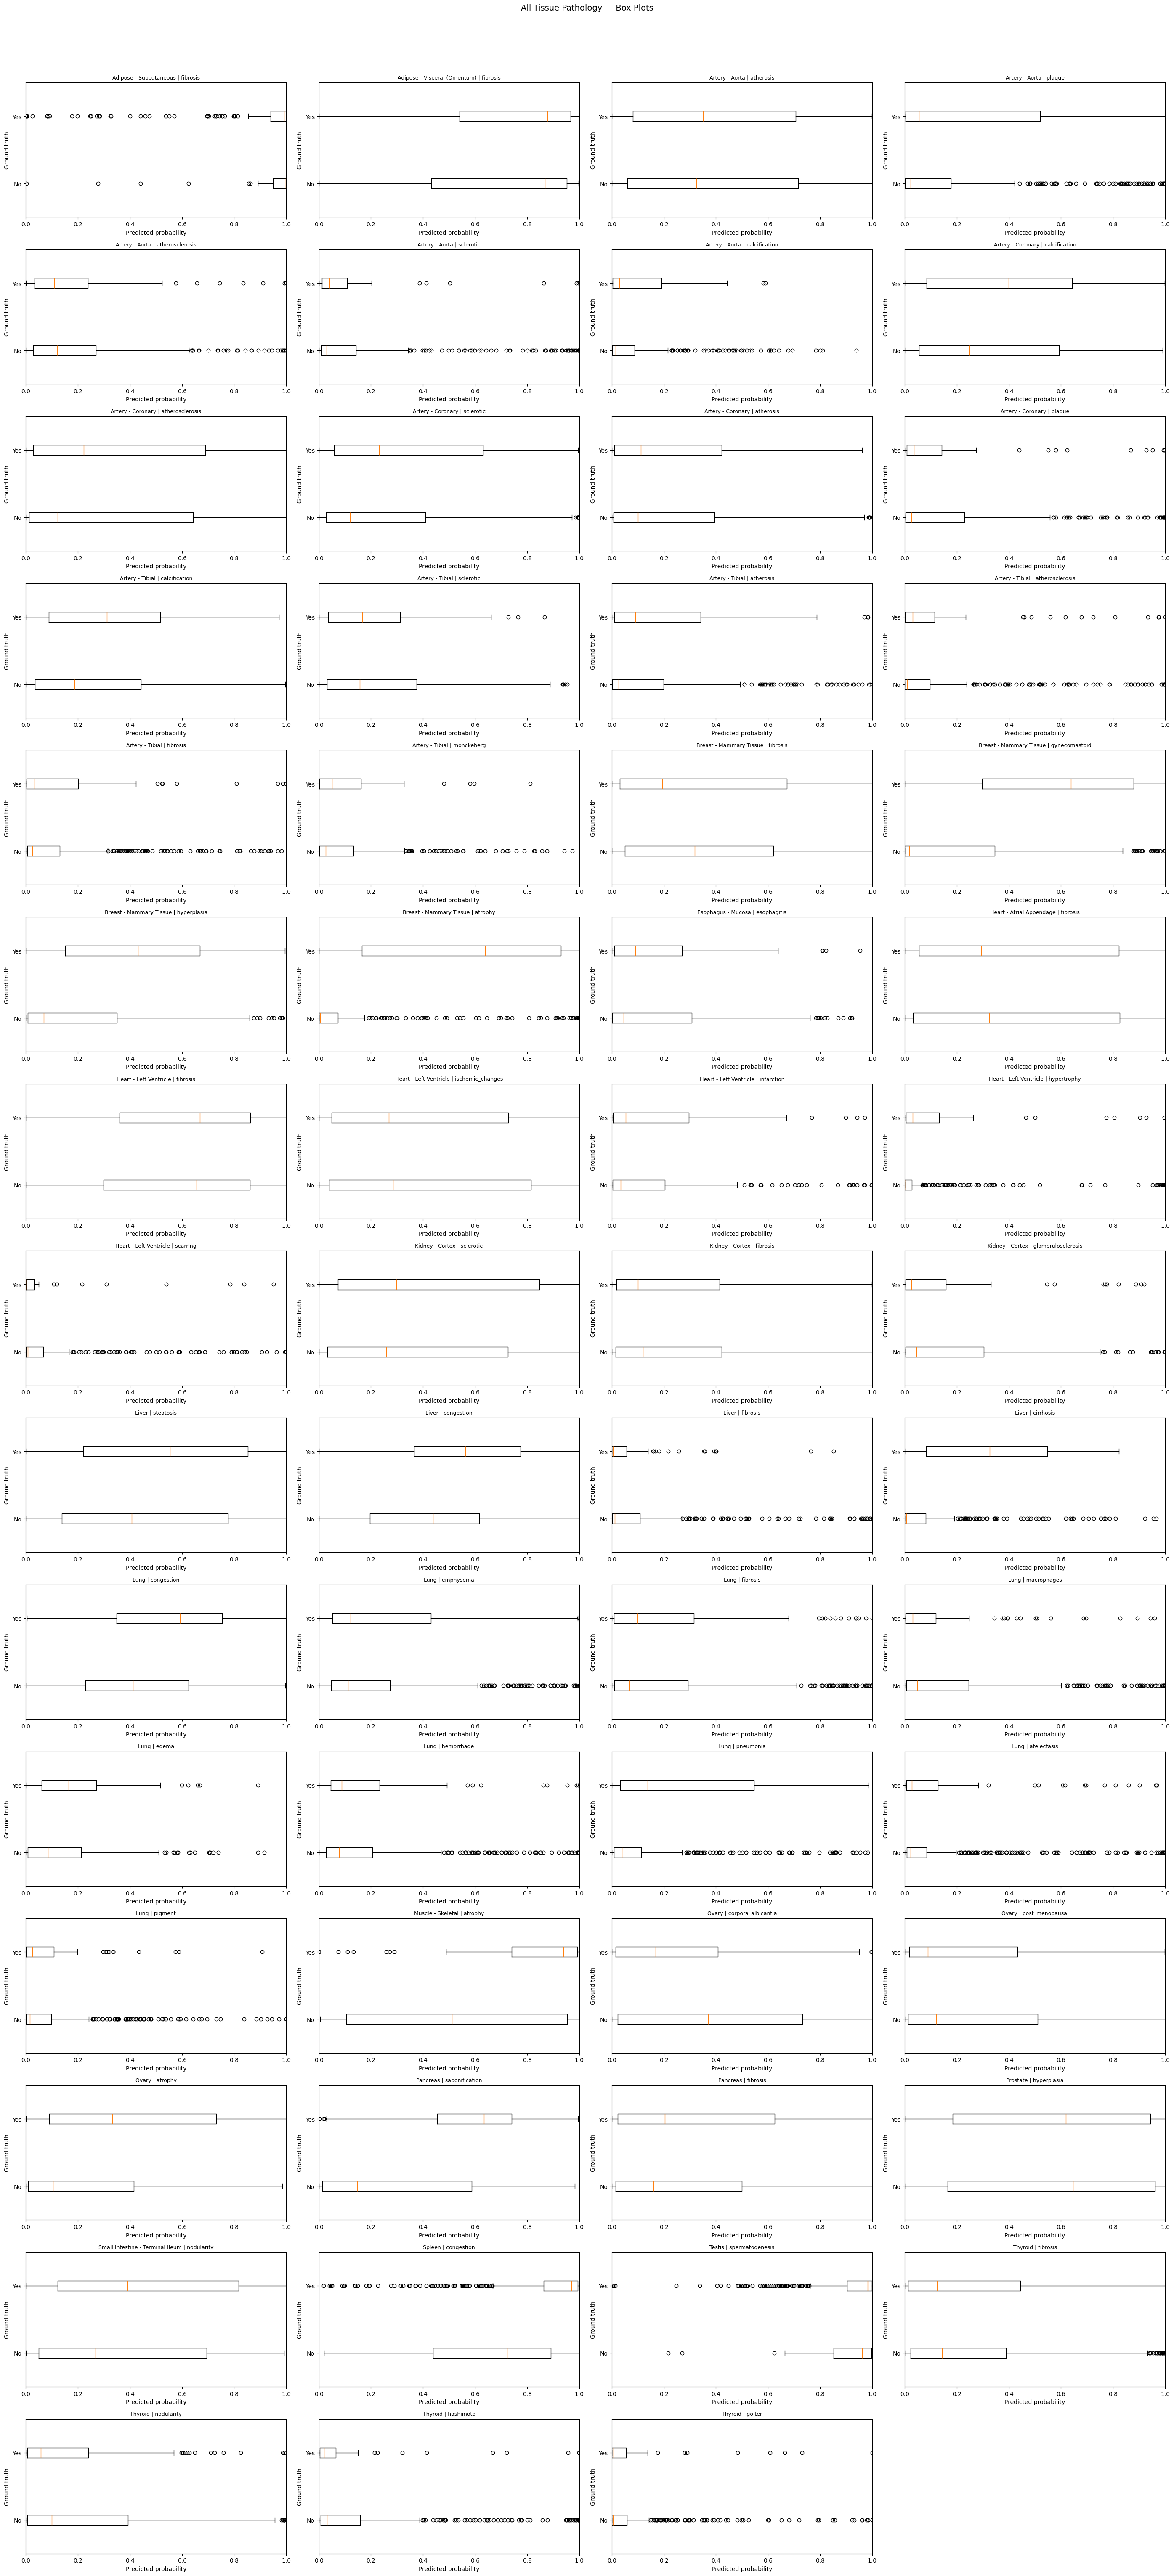

In [4]:
plot_roc_grid(all_tissue_results,
             suptitle="All-Tissue Pathology — ROC (5-fold CV)",
             save_path=Config.FIGURES_DIR / "roc_all_tissue_pathology.pdf")
plot_pr_grid(all_tissue_results,
             suptitle="All-Tissue Pathology — Precision-Recall",
             save_path=Config.FIGURES_DIR / "pr_all_tissue_pathology.pdf")
plot_cm_grid(all_tissue_results,
             suptitle="All-Tissue Pathology — Confusion Matrices",
             save_path=Config.FIGURES_DIR / "cm_all_tissue_pathology.pdf")
plot_boxplot_grid(all_tissue_results,
                  suptitle="All-Tissue Pathology — Box Plots",
                  save_path=Config.FIGURES_DIR / "boxplot_all_tissue_pathology.pdf")